In [38]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [39]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [40]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [41]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [42]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [43]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [44]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [45]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.271508e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,7.165331e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,6.314014e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.389803e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,9.810036e+07


count       333.000000
mean     364557.459112
std      169348.637186
min           0.000000
25%      196315.598988
50%      391430.585333
75%      496662.010120
max      700303.036374
Name: land_value_per_100m2, dtype: float64


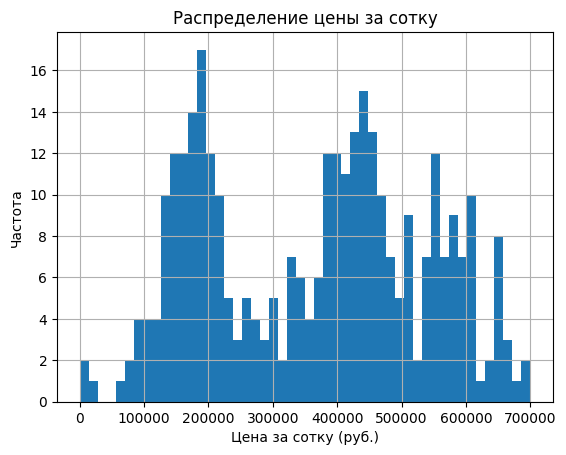

In [46]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()



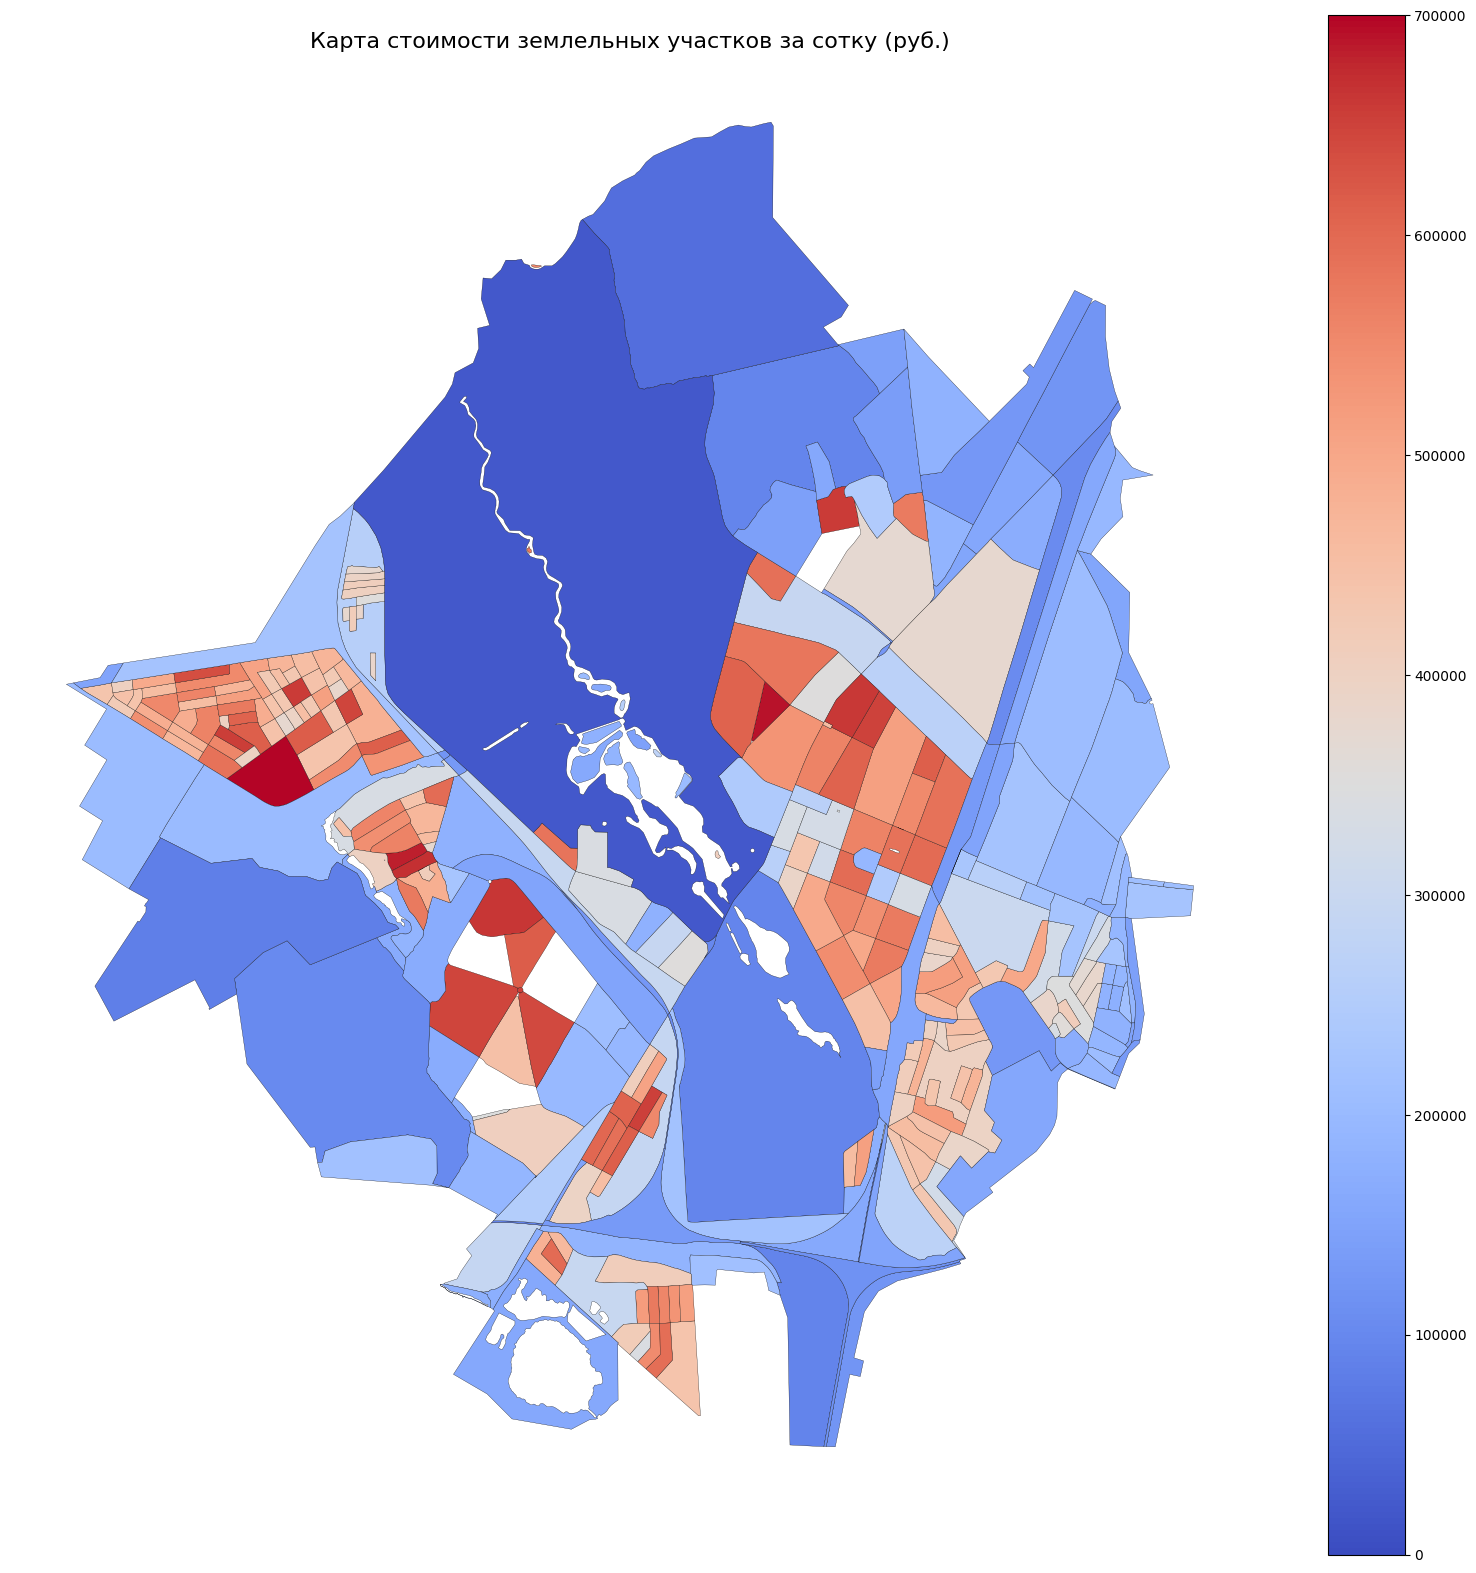

In [47]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

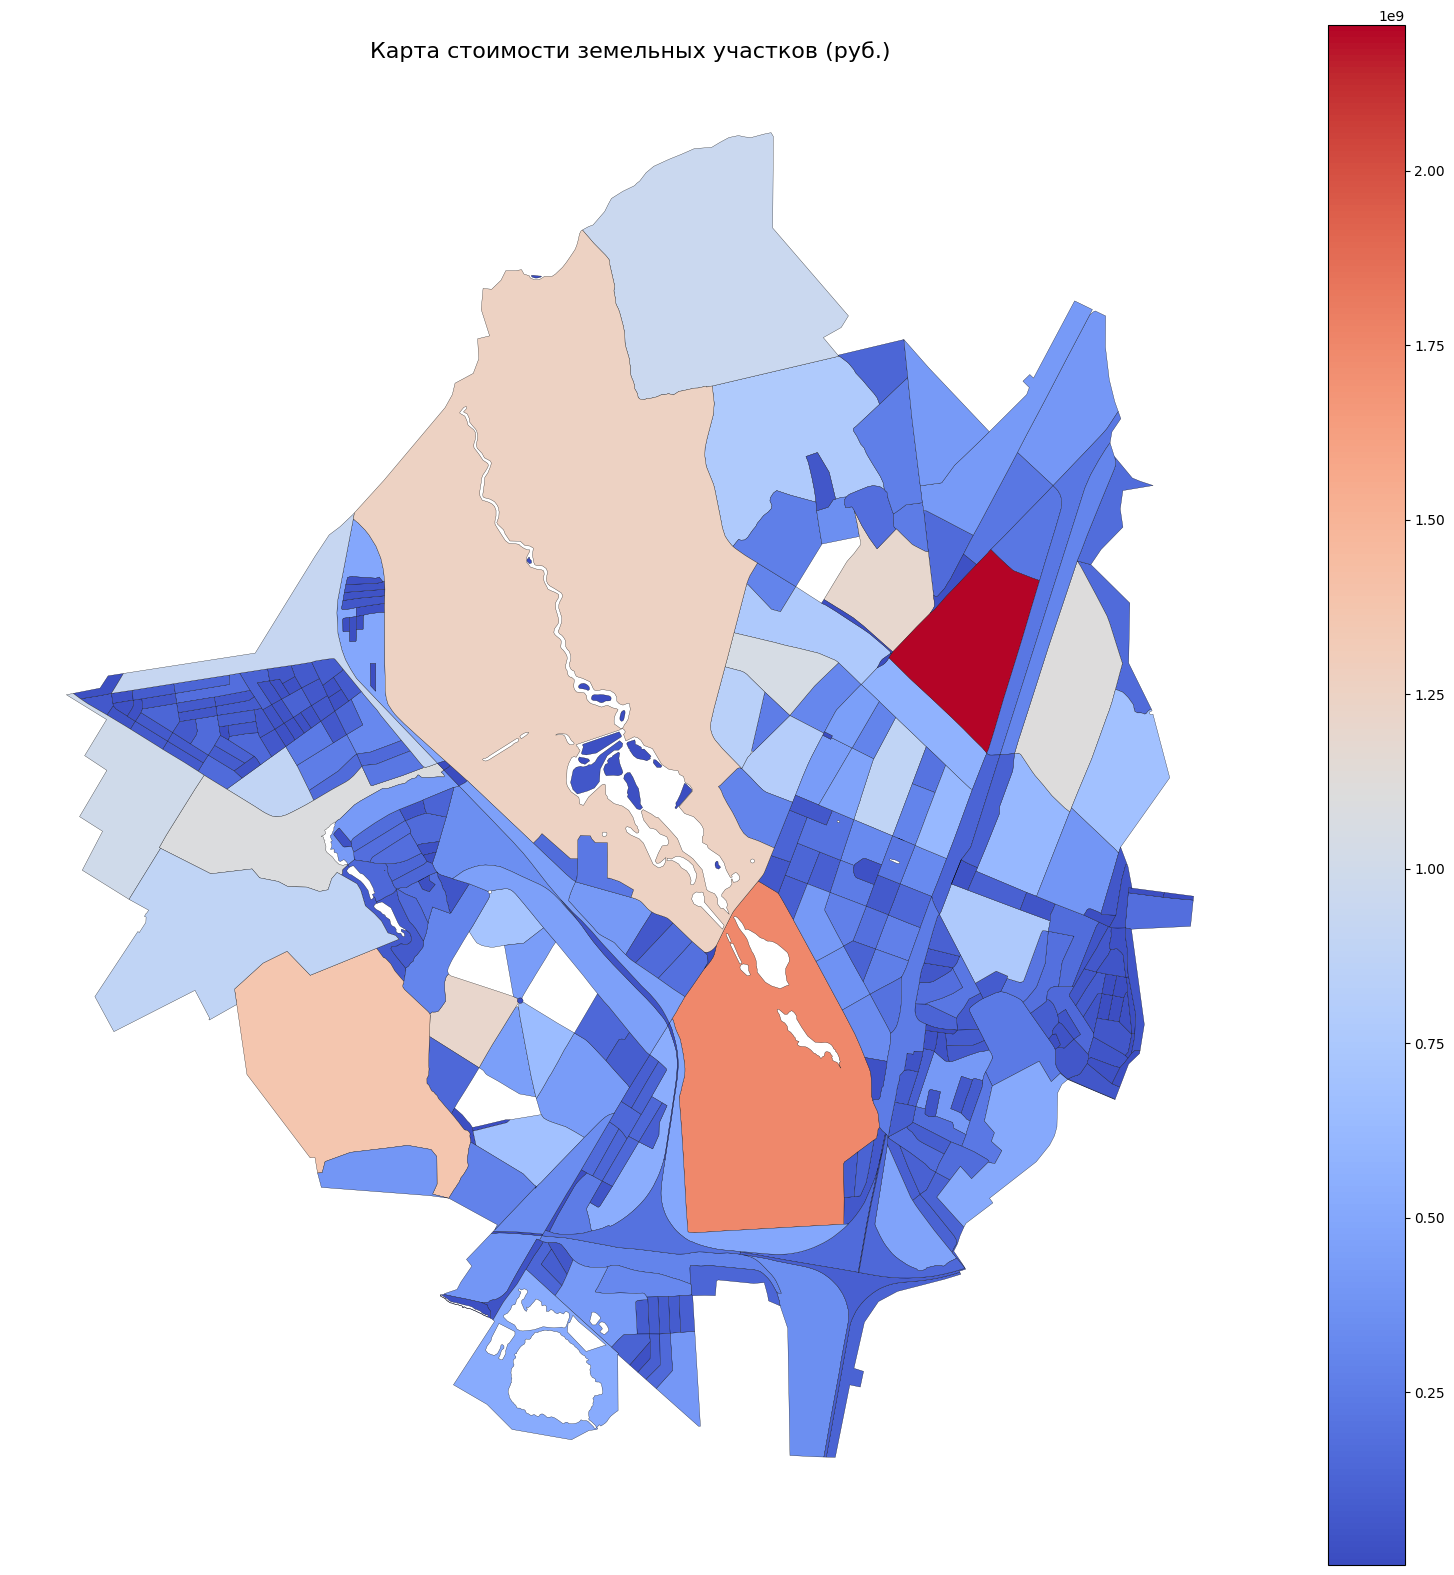

In [48]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [49]:
blocks_clean["id"] = blocks_clean.index

In [50]:
# blocks_clean.to_file("./data/blocks_clean_gatchina.geojson", driver="GeoJSON")

In [51]:
target_id = 86

/tmp/ipykernel_53693/2368820017.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


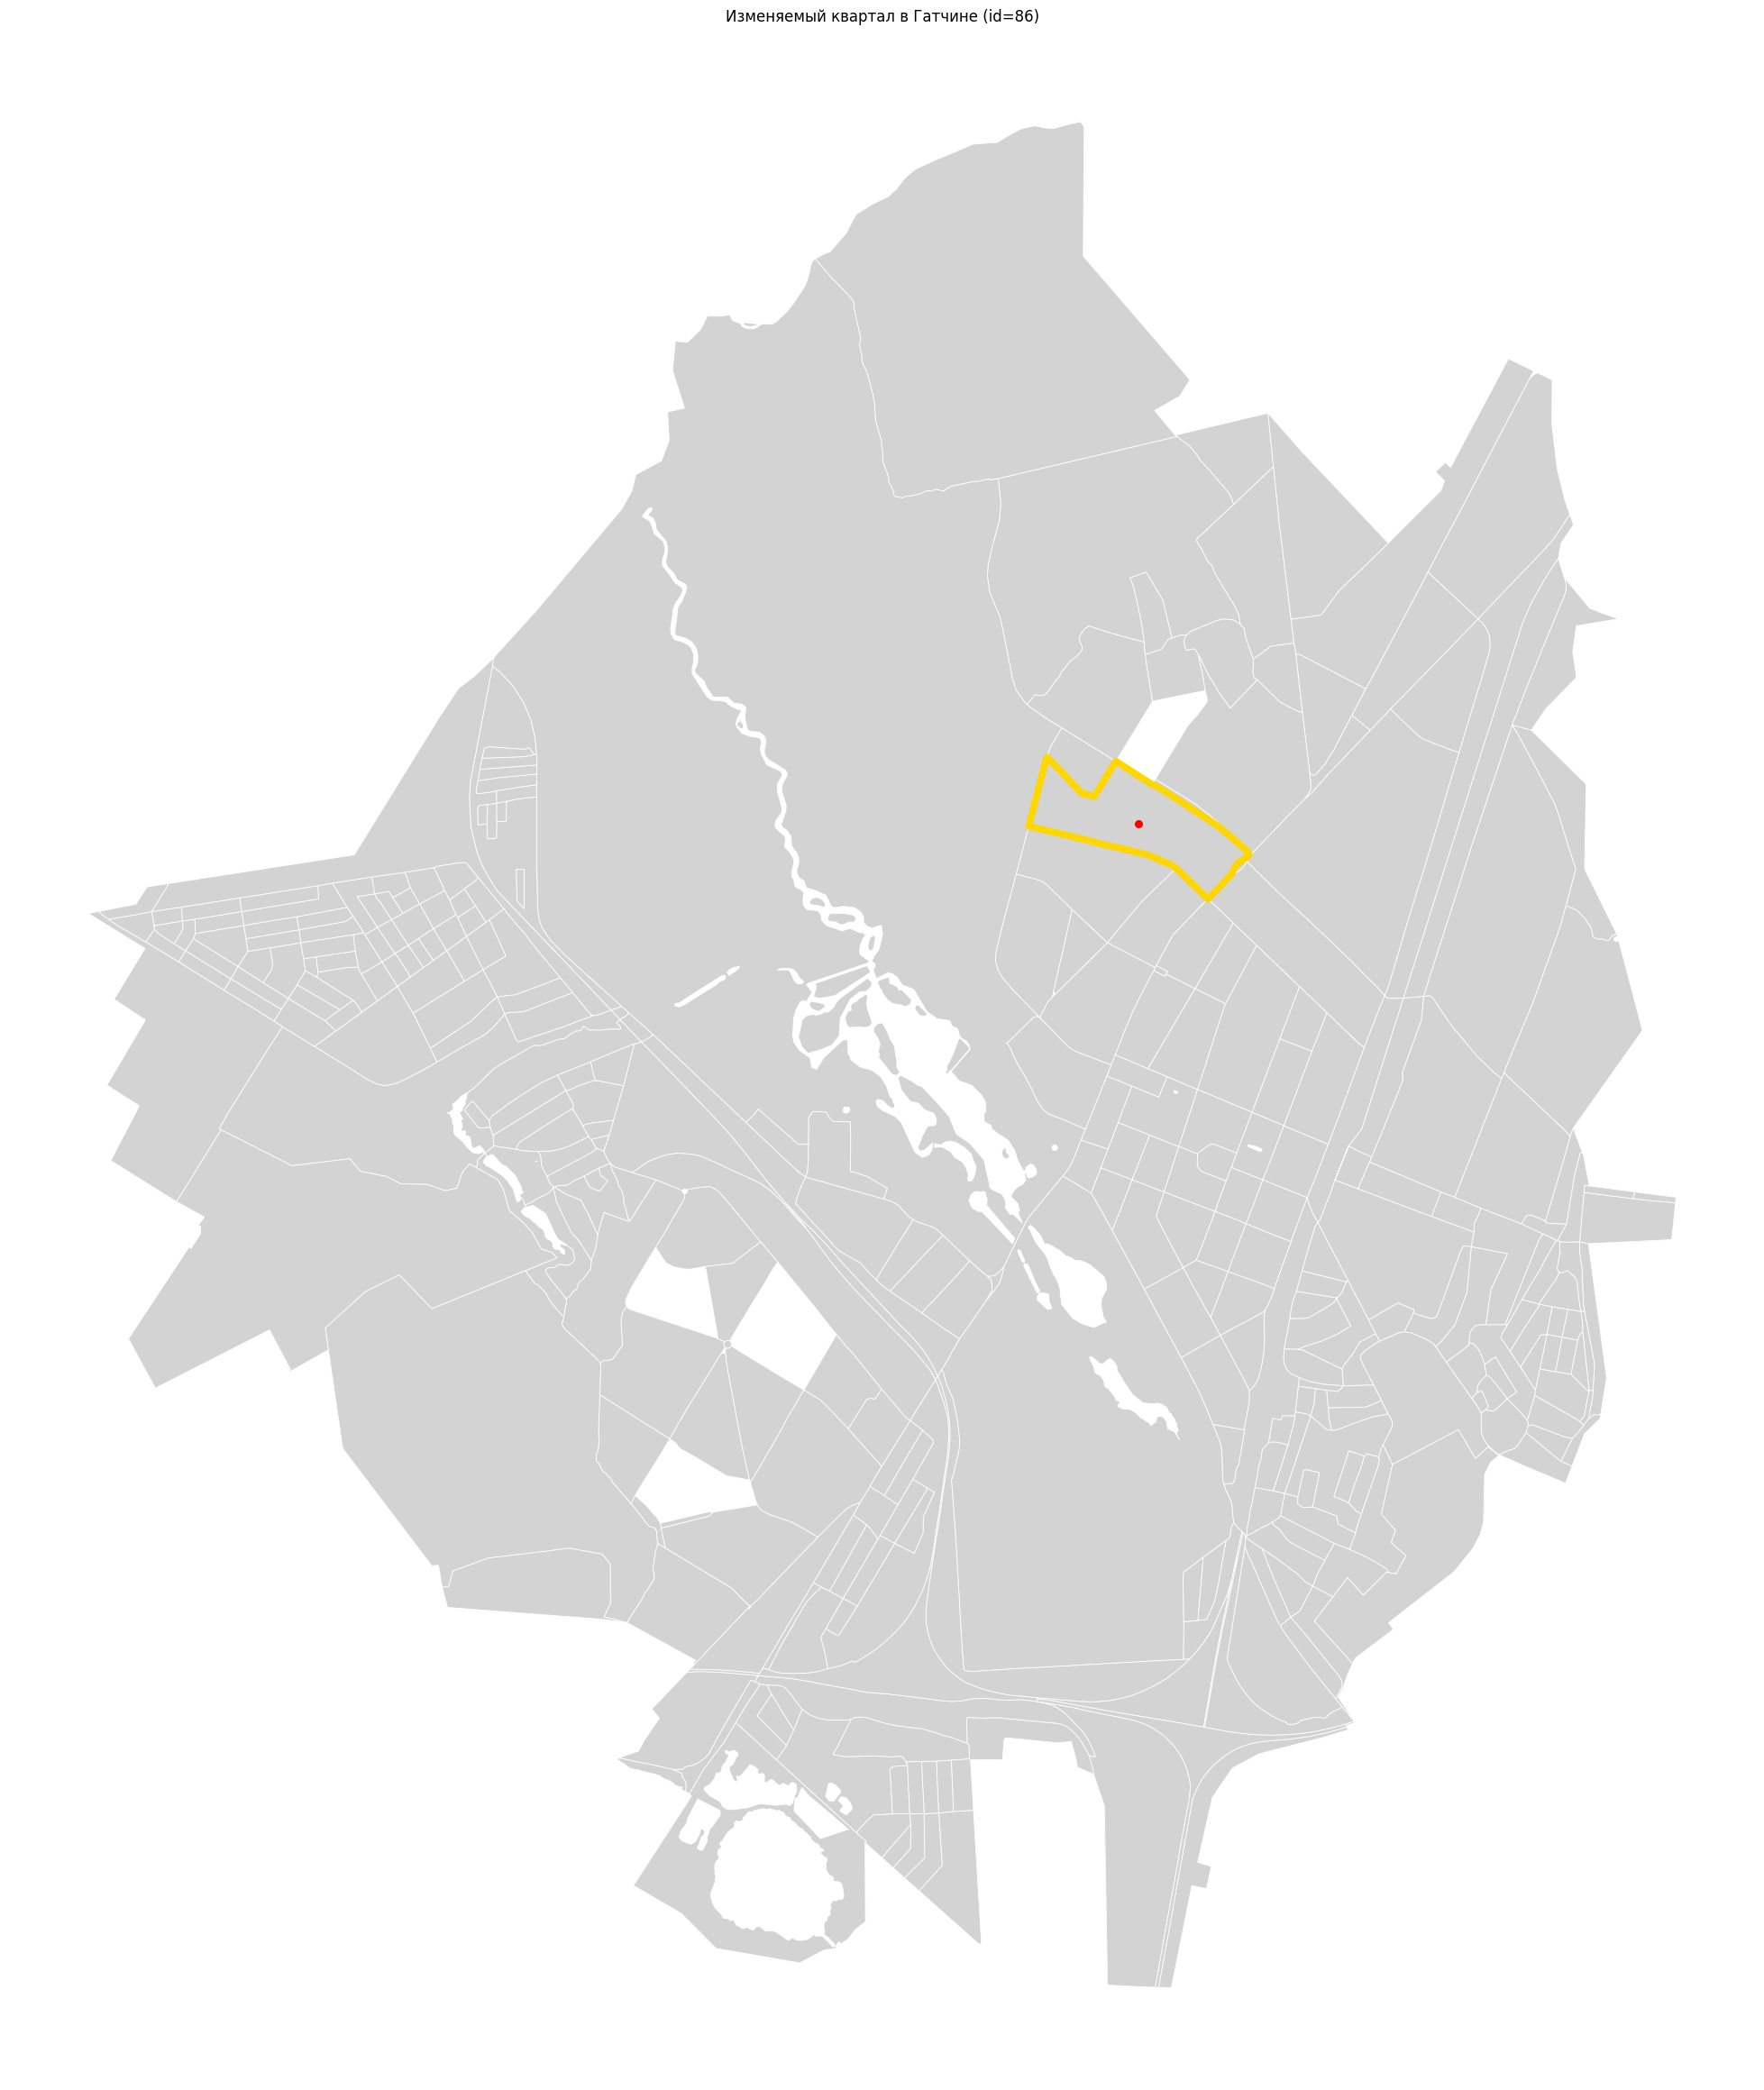

In [52]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал в Гатчине (id={target_id})")
ax.axis("off")
plt.show()


In [53]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

In [54]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
        "cost_demolition": 900,  # ₽/м² ориентировочно по России
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
        "cost_demolition": 900,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
        "cost_demolition": 900,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
        "cost_demolition": 900,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
        "cost_demolition": 900,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
        "cost_demolition": 900,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
        "cost_demolition": 900,
    },
}


## Оптимизация района

In [55]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem

site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])



In [56]:
problem = DistrictProblem(
    blocks=blocks_clean,
    target_id=target_id,
    model=model,
    benchmarks=benchmarks_ru,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

In [57]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=10,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 15),
    seed=42,
    verbose=True,
    save_history=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       10 |      1 |             - |             -
     2 |       20 |      1 |  6.622146E+07 |         ideal
     3 |       30 |      2 |  1.0000000000 |         ideal
     4 |       40 |      1 |  4.449188E+08 |         ideal
     5 |       50 |      1 |  4.882480E+07 |         ideal
     6 |       60 |      4 |  0.9978987572 |         ideal
     7 |       70 |      1 |  1.376257E+08 |         ideal
     8 |       80 |      3 |  0.4808934655 |         ideal
     9 |       90 |      2 |  1.1076620282 |         ideal
    10 |      100 |      1 |  2.458242E+08 |         ideal
    11 |      110 |      2 |  1.0000000000 |         ideal
    12 |      120 |      3 |  0.0479566371 |         ideal
    13 |      130 |      3 |  0.1803217805 |         ideal
    14 |      140 |      4 |  0.0137609835 |         ideal
    15 |      150 |      4 |  0.1785858123 |         ideal


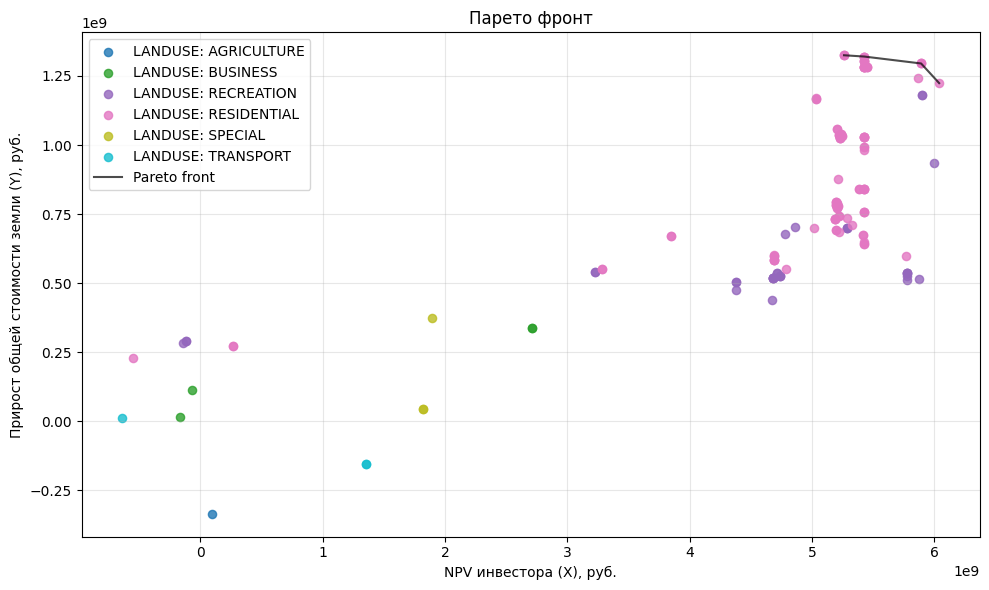

In [58]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [59]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[2.58305156e+04 8.71271366e+00 9.94426872e-01 9.11055762e-01
  5.50070747e-01 8.88484953e-01 1.81082627e-03 2.12207414e-01
  7.52473742e-03 6.00768040e-03]
 [2.53909822e+04 9.52733647e+00 9.94575729e-01 9.16674368e-01
  6.11031424e-01 9.11583257e-01 7.92877241e-03 2.12207414e-01
  7.52473742e-03 6.00768040e-03]
 [2.58305156e+04 8.48108934e+00 9.94426872e-01 9.11055762e-01
  5.50123313e-01 8.89680803e-01 1.12972514e-03 2.60781112e-01
  7.36326558e-03 8.29694965e-04]
 [2.58316047e+04 9.55827056e+00 9.99340261e-01 9.32726697e-01
  5.17543632e-01 8.96140117e-01 1.99684487e-02 2.61225966e-01
  7.52473742e-03 6.00762519e-03]]
Значения целевых функций:
 [[6.76250105e+10 5.42798908e+09]
 [6.75998914e+10 5.89321567e+09]
 [6.76296432e+10 5.26309057e+09]
 [6.75287882e+10 6.04091646e+09]]


In [60]:
len(res.opt)

4

In [61]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(25830.515598412425),
 'l': np.float64(8.481089344531213),
 'mxi': np.float64(0.9944268722666413),
 'residential': np.float64(0.9110557615339625),
 'business': np.float64(0.5501233128763132),
 'recreation': np.float64(0.8896808034054883),
 'industrial': np.float64(0.0011297251428638577),
 'transport': np.float64(0.2607811116296136),
 'special': np.float64(0.0073632655817730385),
 'agriculture': np.float64(0.0008296949646516005)}

In [62]:
# params_optimal = {param: res.X[4][i] for i, param in enumerate(problem.constraints.keys())}
# params_optimal

In [63]:
idx = idx_city

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 25830.515598412425,
  'l': 8.481089344531213,
  'mxi': 0.9944268722666413,
  'residential': 0.3476033529870085,
  'business': 0.20989352813065892,
  'recreation': 0.33944797169299806,
  'industrial': 0.0004310342617799966,
  'transport': 0.09949817851489856,
  'special': 0.0028093733811075084,
  'agriculture': 0.00031656103154843247,
  'share': 0.3476033529870085,
  'land_use': <LandUse.RESIDENTIAL: 'residential'>,
  'build_floor_area': 219070.9106054429,
  'living_area': 217850.00043797557,
  'non_living_area': 1220.9101674673439,
  'population': 10892.500021898779,
  'fsi': 0.8353483018094133,
  'gsi': 0.09849540169601723,
  'morphotype': 'mid-rise'},
 'land_value_after': 67629643204.77289,
 'land_value_gain': 1325053394.3119965,
 'investor_npv': 5263090570.92}

# Визуализация прироста стоимости земли

Изменение стоимости земли по всем кварталам:
 • Сумма до:    66 304 589 810 ₽
 • Сумма после: 67 629 643 205 ₽
 • Изм.  ₽:     +1 325 053 394 ₽
 • Изм., %:     +2.00%

Изменяемый квартал:
 • До: 741 498 772 ₽ | После: 978 601 523 ₽ | Δ: +237 102 751 ₽ | Δ%: +31.98%


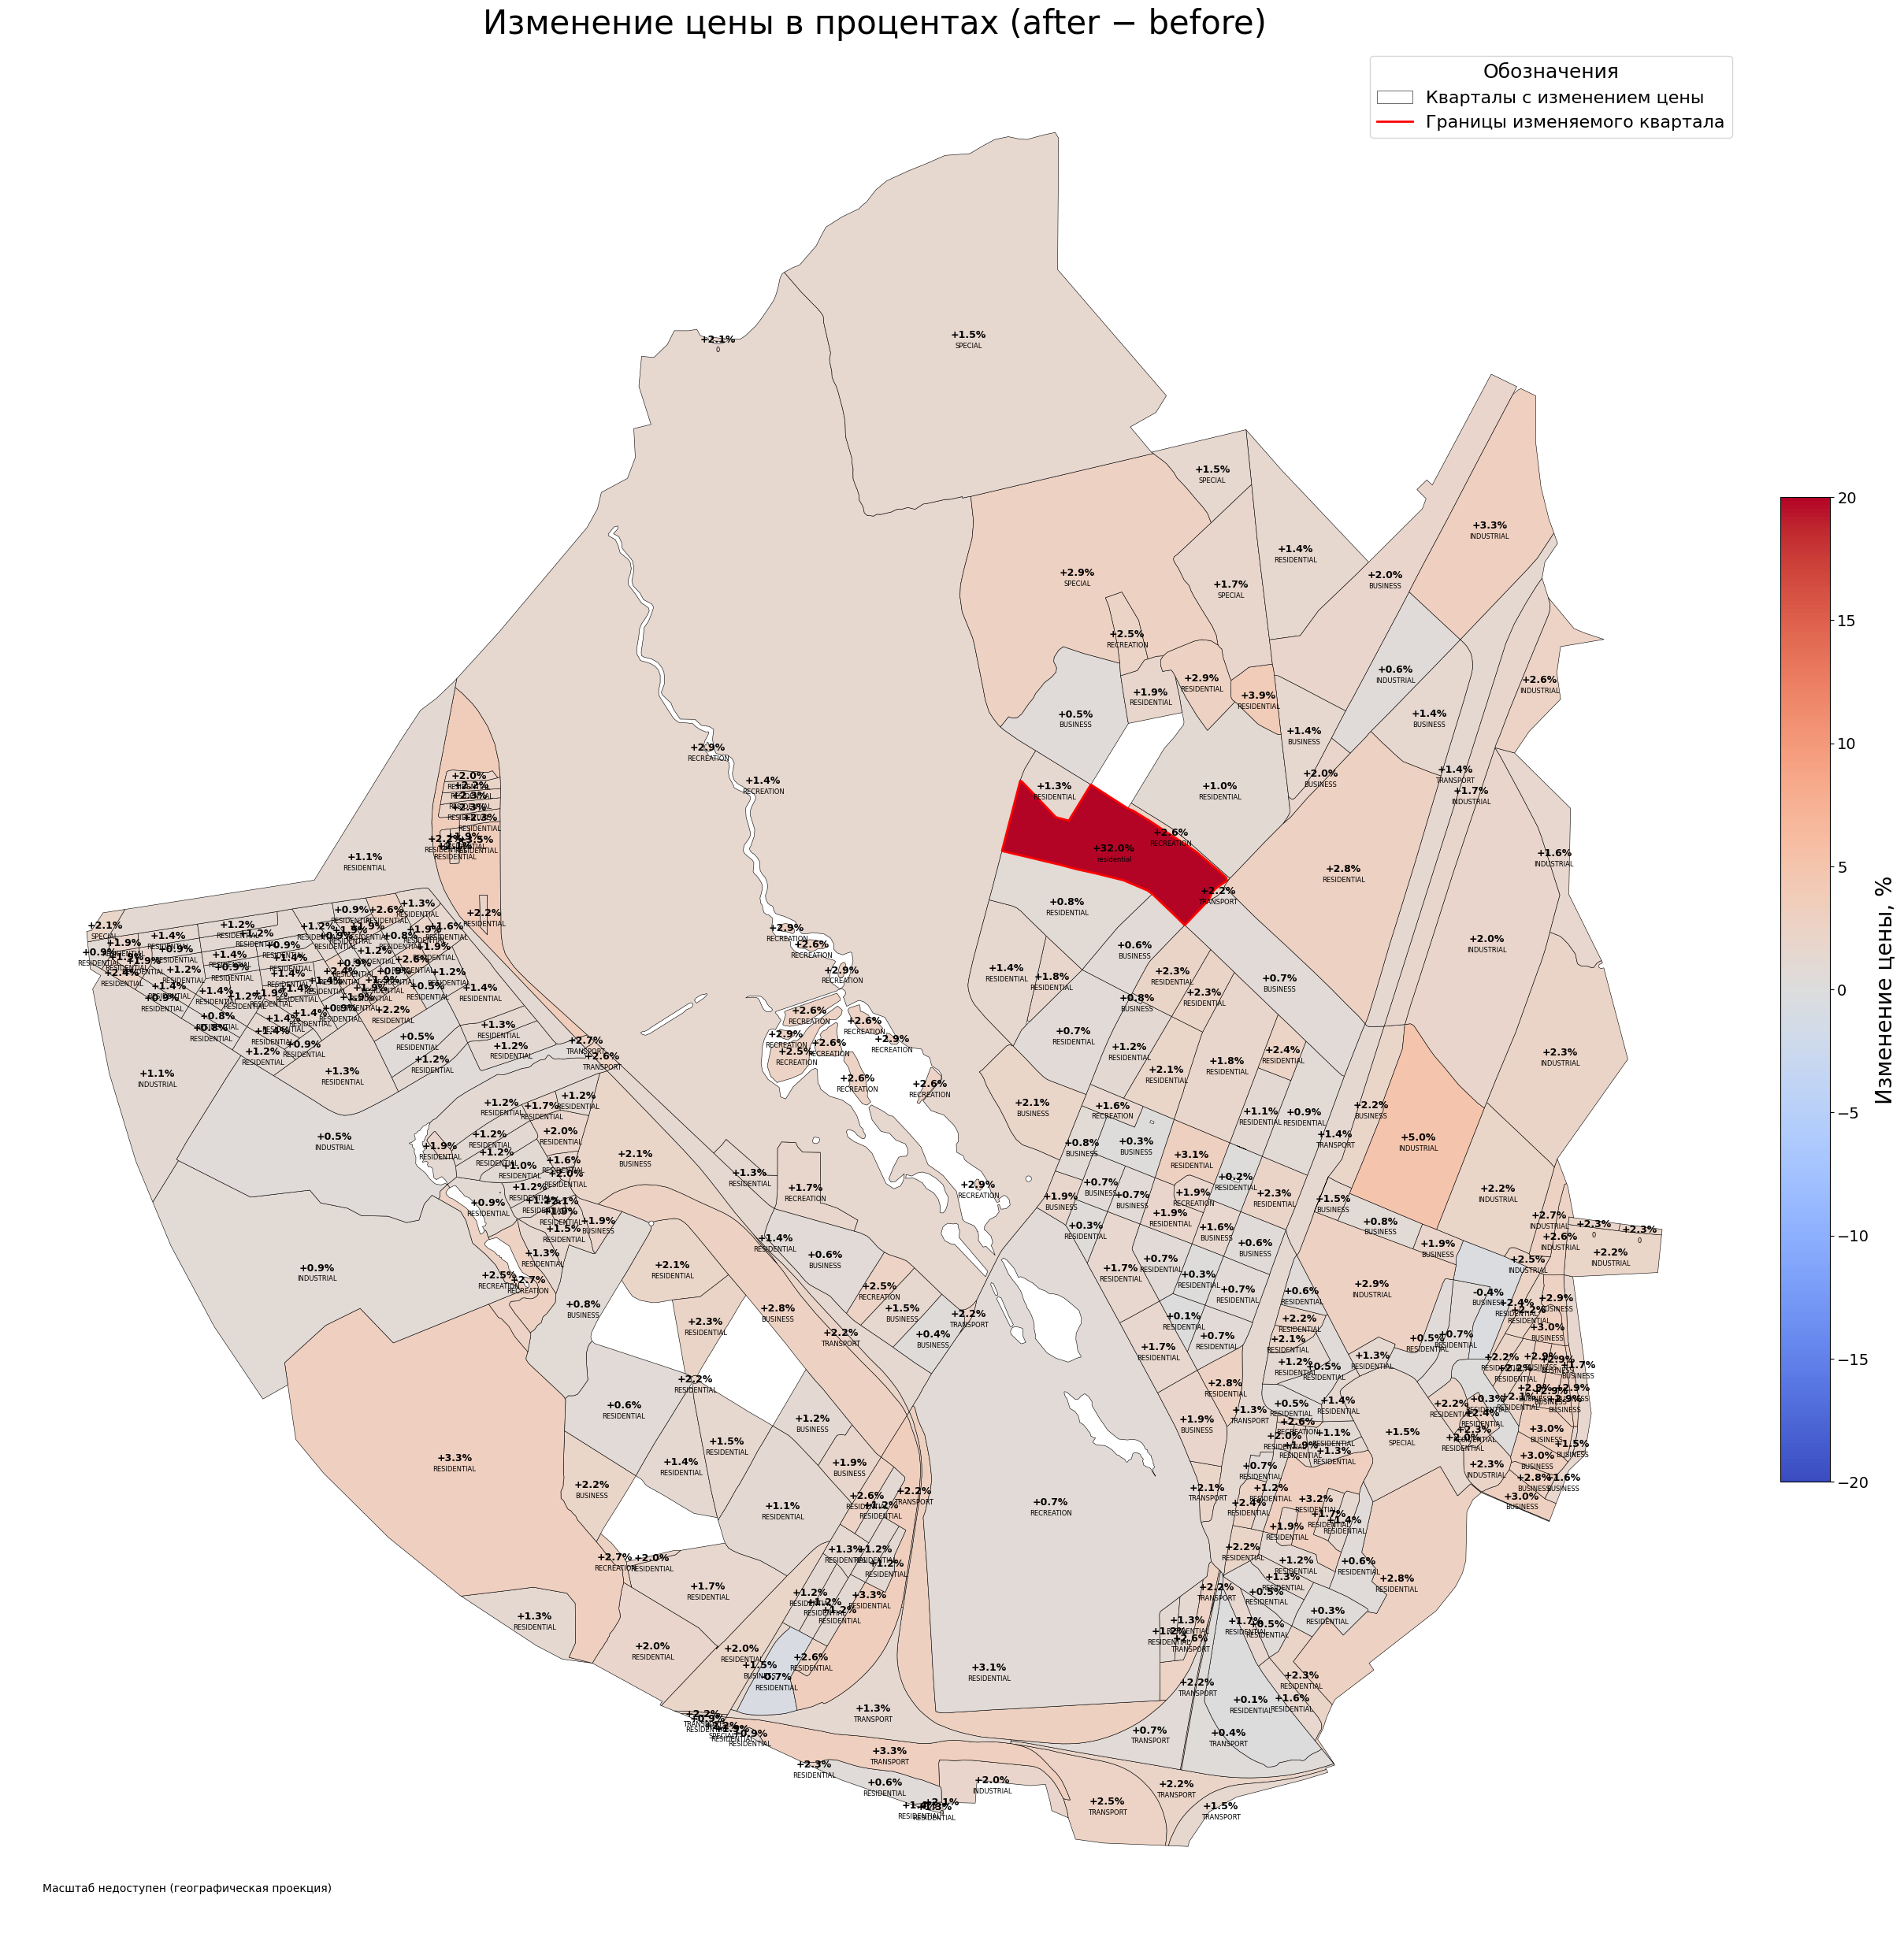

In [64]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)



# Инвестиционная привлекательность

In [65]:
import pandas as pd

blocks_gen = modifier.apply(target_id, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,morphotype,area_accessibility,geometry,site_area,land_value,land_value_per_100m2,id,is_project,land_use_before,build_floor_area_before
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.271508e+08,198287.088263,0,False,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,7.165331e+08,662432.386253,1,False,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.389803e+08,433524.025358,3,False,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,9.810036e+07,318721.270922,4,False,NaN,NaN
5,0.262580,0.000000,0.000186,0.0,0.737236,0.0,0.0,LandUse.TRANSPORT,0.737236,1946.641824,...,individual residential,10.294833,"POLYGON ((30.13162 59.55046, 30.1319 59.55029,...",37909.234921,6.740563e+07,177807.938604,5,False,NaN,NaN


In [66]:
gen_blocks.loc[gen_blocks["id"] == 86].iloc[0]

residential                                                         0.347603
business                                                            0.209894
recreation                                                          0.339448
industrial                                                          0.000431
transport                                                           0.099498
special                                                             0.002809
agriculture                                                         0.000317
land_use                                                 LandUse.RESIDENTIAL
share                                                               0.347603
footprint_area                                                  25830.515598
build_floor_area                                               219070.910605
living_area                                                    217850.000438
non_living_area                                                  1220.910167

In [67]:
blocks_before.loc[blocks_before["id"] == 86].iloc[0]

residential                                                      0.268468
business                                                         0.648297
recreation                                                       0.065871
industrial                                                            0.0
transport                                                         0.01739
special                                                               0.0
agriculture                                                           0.0
land_use                                                 LandUse.BUSINESS
share                                                            0.648297
footprint_area                                               47096.975151
build_floor_area                                            107107.690178
living_area                                                  44241.785252
non_living_area                                              62865.904925
population                            

In [68]:
from urbanomy.methods.investment_potential import prepare_investment_input

investment_input = prepare_investment_input(
    gdf = gen_blocks
)

investment_input.head()


2026-03-17 14:00:37.225 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:274 - prepare_investment_input: колонка 'land_value_before' не найдена; значение оставлено пустым, текущая цена записана в 'land_value_after'.


,land_use,land_value,residential,business,recreation,industrial,transport,special,agriculture,site_area,living_area,non_living_area,build_floor_area,land_use_before,build_floor_area_before
0,LandUse.RESIDENTIAL,7.691950e+08,91159.319895,55044.783401,89020.56316,113.039157,26093.494802,736.760922,83.018441,262250.979778,217850.000438,1220.910167,219070.910605,LandUse.BUSINESS,107107.690178


In [69]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          262,250.98
 • Built area:         219,070.91
 • Land value:         769,194,999.43
 • Demolition cost:    96,396,921.16
 • Construction cost:  9,841,140,147.35
 • Investment need:    10,706,732,067.94
 • Project NPV:        5,263,090,570.92
 • Project IRR:        0.35
 • Project PI:         1.57
 • Project PP (yrs):   5.24


,land_use,land_area,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,PI,PP_years,EI
0,LandUse.RESIDENTIAL,262250.98,219070.91,7.691950e+08,96396921.16,9.841140e+09,1.070673e+10,5.263091e+09,0.35,1.57,5.24,100.0


# LLM 1

In [70]:
import os
import json
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
    run_pareto_vote,
)

load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("CHAT_MODEL"),
    base_url=os.getenv("BASE_URL") + "/v1",
    temperature=float(os.getenv("TEMPERATURE", "0")),
    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
)




In [71]:
pareto_front_df = build_pareto_front_dataframe(
    res=res,
    problem=problem,
    baseline_land_value=baseline_land_value,  # если уже посчитан
    use_history=False,                        # True если хочешь взять все решения из history
    scenario_prefix="scenario",
)

In [ ]:
# pareto_front_df.to_pickle("pareto_front_df.pkl")


In [ ]:
pareto_front_df = build_pareto_front_dataframe(
    res=res,
    problem=problem,
    baseline_land_value=baseline_land_value,  # если уже посчитан
    use_history=False,                        # True если хочешь взять все решения из history
    scenario_prefix="scenario",
)

result = run_pareto_vote(
    pareto_front_df,
    llm=llm,
    additional_context=(
        "Нужно выбрать лучший сценарий из парето-фронта. "
        "Важно учитывать баланс городской выгоды, качества жизни и доходности."
    ),
    scenario_id_column="scenario_id",
    title_column="title",
    summary_column="summary",
)



In [ ]:
from urbanomy.methods.land_value_modeling import (
    run_pareto_vote,
    ask_winner_scenario_question,
)

qa_result = ask_winner_scenario_question(
    result=result,
    llm=llm,
    question="Какие главные риски у выбранного сценария для жителей?",
)
